<center><b>Student Performance Prediction</b></center>

In [209]:
#importing libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [210]:
#reading the dataset
df = pd.read_csv("Student_Performance.csv")
df.head(5)

,Unnamed: 0,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1.0,91
1,4,82,No,4,2.0,65
2,8,51,Yes,7,2.0,45
3,5,52,Yes,5,2.0,36
4,7,75,No,8,5.0,66


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        8428 non-null   object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  7144 non-null   float64
 5   Performance Index                 10000 non-null  int64  
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [212]:
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df.head()

,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,99,Yes,9,1.0,91
1,82,No,4,2.0,65
2,51,Yes,7,2.0,45
3,52,Yes,5,2.0,36
4,75,No,8,5.0,66


In [213]:
df.nunique().sort_values(ascending=False)

Performance Index                   91
Previous Scores                     60
Sample Question Papers Practiced    10
Sleep Hours                          6
Extracurricular Activities           2
dtype: int64

In [214]:
df.describe()

,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,7144.000000,10000.000000
mean,69.445700,6.530600,4.572788,55.224800
std,17.343152,1.695863,2.868633,19.212558
min,40.000000,4.000000,0.000000,10.000000
25%,54.000000,5.000000,2.000000,40.000000
50%,69.000000,7.000000,5.000000,55.000000
75%,85.000000,8.000000,7.000000,71.000000
max,99.000000,9.000000,9.000000,100.000000


In [215]:
df.isnull().sum()

Previous Scores                        0
Extracurricular Activities          1572
Sleep Hours                            0
Sample Question Papers Practiced    2856
Performance Index                      0
dtype: int64

<Axes: >

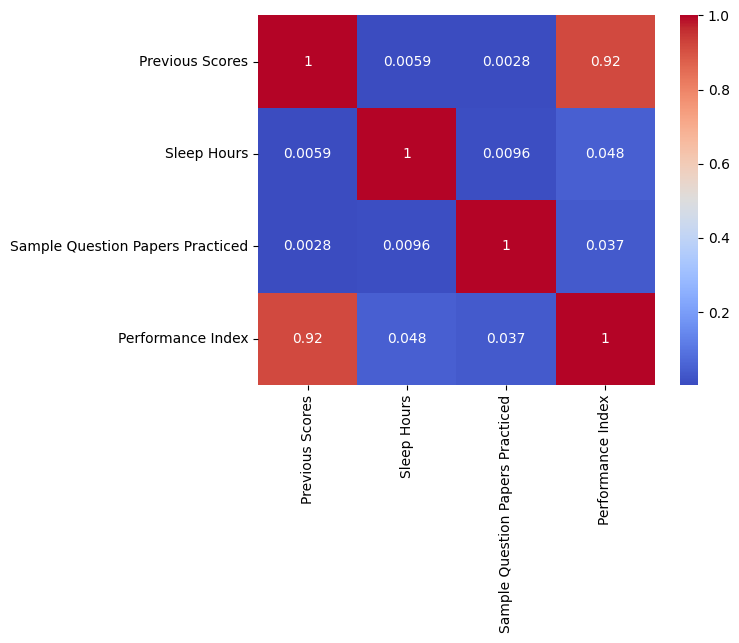

In [216]:
# Visualize the correlation matrix
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [217]:
#Imputing missing values using median strategy
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')

In [218]:
df[["Sample Question Papers Practiced"]] = imputer.fit_transform(df[["Sample Question Papers Practiced"]])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Previous Scores                   10000 non-null  int64  
 1   Extracurricular Activities        8428 non-null   object 
 2   Sleep Hours                       10000 non-null  int64  
 3   Sample Question Papers Practiced  10000 non-null  float64
 4   Performance Index                 10000 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 390.8+ KB


In [219]:
df.columns

Index(['Previous Scores', 'Extracurricular Activities', 'Sleep Hours',
       'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [220]:
imputer = SimpleImputer(strategy='most_frequent')
df[["Extracurricular Activities"]] = imputer.fit_transform(df[["Extracurricular Activities"]])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Previous Scores                   10000 non-null  int64  
 1   Extracurricular Activities        10000 non-null  object 
 2   Sleep Hours                       10000 non-null  int64  
 3   Sample Question Papers Practiced  10000 non-null  float64
 4   Performance Index                 10000 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 390.8+ KB


In [221]:
df.reset_index(drop=True, inplace=True)
df.head()

,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,99,Yes,9,1.0,91
1,82,No,4,2.0,65
2,51,Yes,7,2.0,45
3,52,Yes,5,2.0,36
4,75,No,8,5.0,66


In [222]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()
Extracurricular_Activities_new = ohe.fit_transform(df[["Extracurricular Activities"]])
Extracurricular_Activities_new.shape

(10000, 2)

In [223]:
Extracurricular_Activities_new_df = pd.DataFrame(Extracurricular_Activities_new.toarray(), columns=ohe.get_feature_names_out(["Extracurricular Activities"]))
Extracurricular_Activities_new_df.head()

df = pd.concat([df, Extracurricular_Activities_new_df], axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Previous Scores                   10000 non-null  int64  
 1   Extracurricular Activities        10000 non-null  object 
 2   Sleep Hours                       10000 non-null  int64  
 3   Sample Question Papers Practiced  10000 non-null  float64
 4   Performance Index                 10000 non-null  int64  
 5   Extracurricular Activities_No     10000 non-null  float64
 6   Extracurricular Activities_Yes    10000 non-null  float64
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


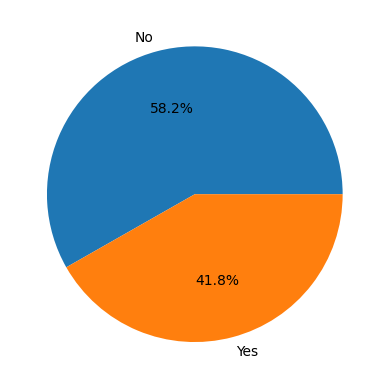

In [224]:
plt.pie(df["Extracurricular Activities"].value_counts(), labels=df["Extracurricular Activities"].value_counts().index, autopct='%1.1f%%')
plt.show()

In [225]:
df.drop("Extracurricular Activities", axis=1, inplace=True)

<Axes: >

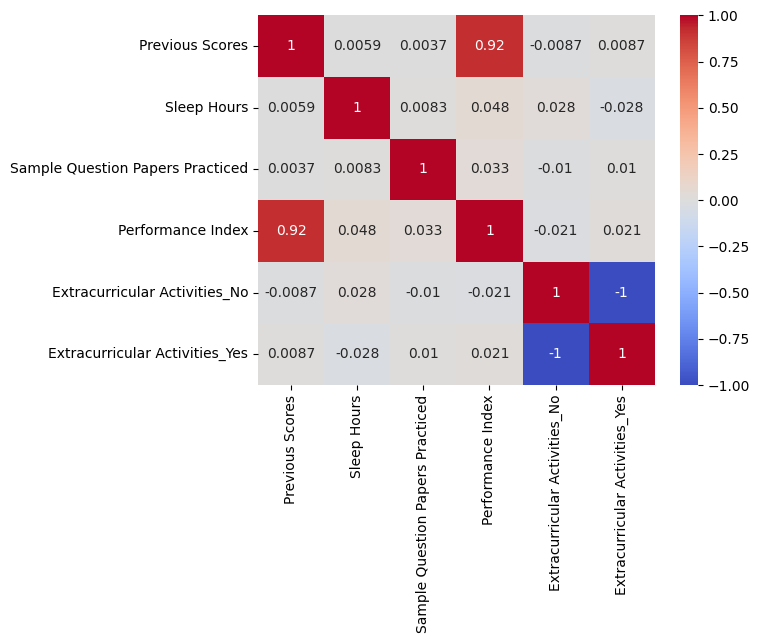

In [226]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

In [227]:
df.columns

Index(['Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced',
       'Performance Index', 'Extracurricular Activities_No',
       'Extracurricular Activities_Yes'],
      dtype='object')

<Axes: xlabel='Sample Question Papers Practiced', ylabel='Performance Index'>

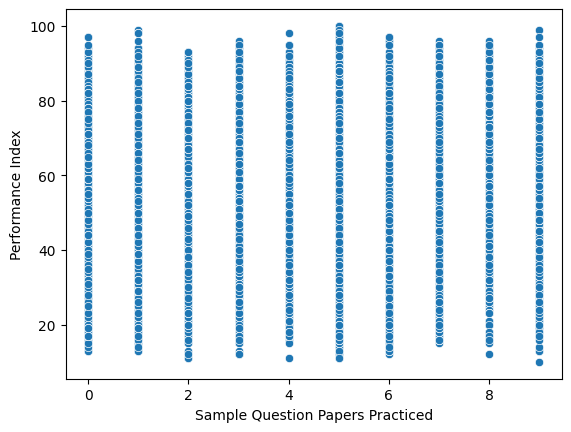

In [228]:
sns.scatterplot(data=df, x="Sample Question Papers Practiced", y="Performance Index")

<Axes: xlabel='Previous Scores', ylabel='Performance Index'>

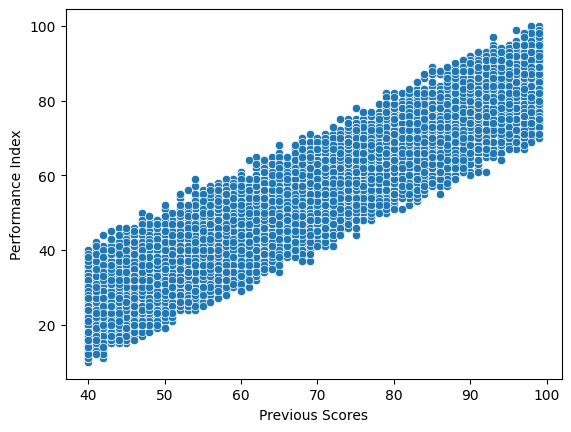

In [229]:
sns.scatterplot(x="Previous Scores", y="Performance Index", data=df)

<Axes: >

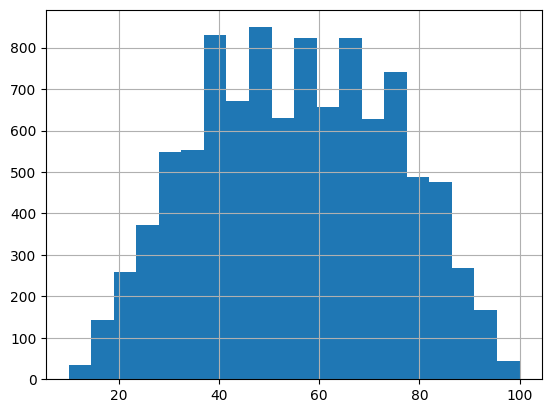

In [230]:
df["Performance Index"].hist(bins=20)

In [231]:
df["Performance Index"].skew()

np.float64(-0.0017400273072201125)

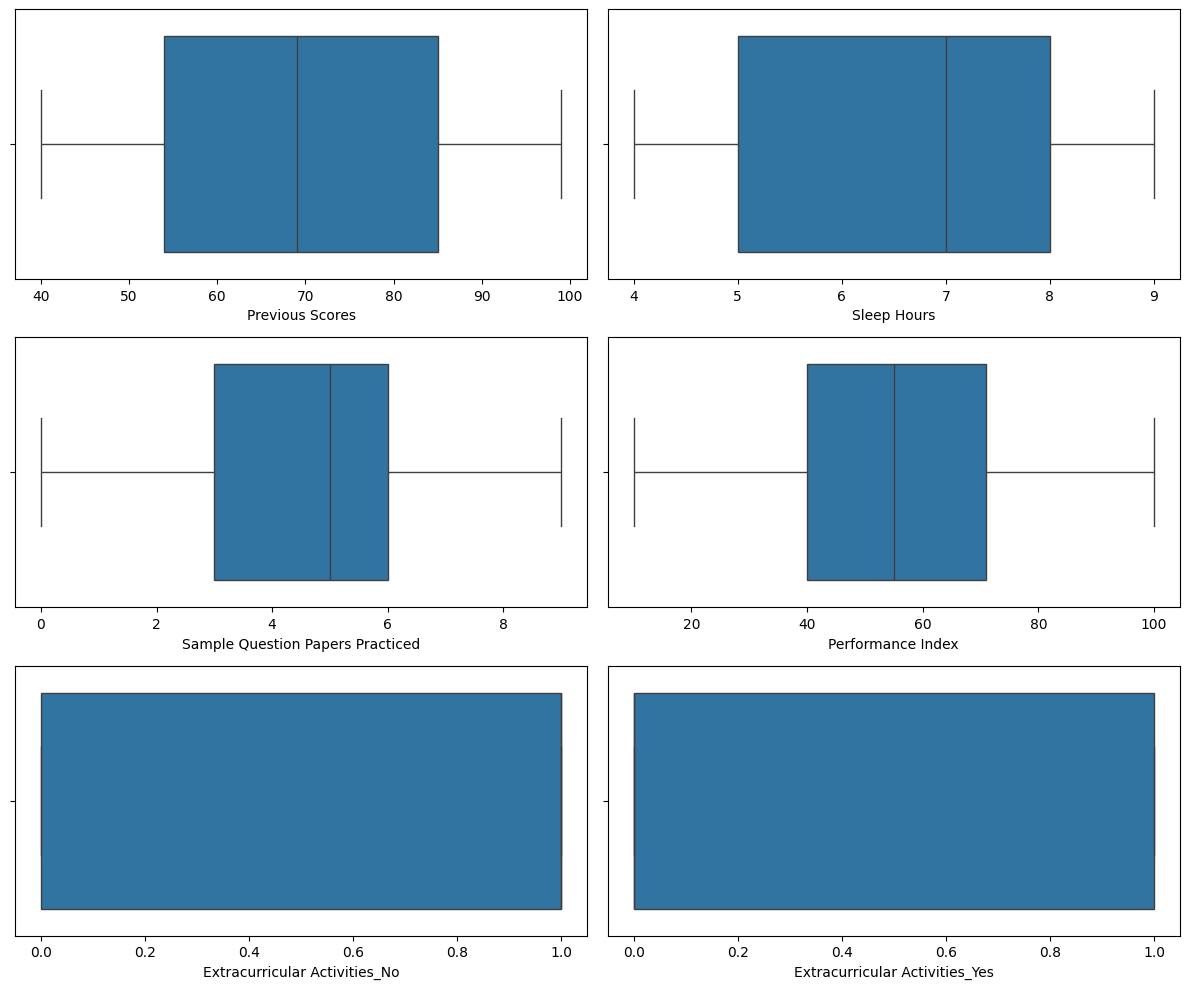

In [232]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

numeric_cols = df.select_dtypes(include="number").columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i])

plt.tight_layout()
plt.show()

In [233]:
from sklearn.model_selection import train_test_split
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [234]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [235]:
from sklearn.linear_model import LinearRegression,Lasso, Ridge
LR = LinearRegression()

LR.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [236]:
y_pred = LR.predict(X_test_scaled)

In [237]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [238]:
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R-squared Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))

Mean Squared Error (MSE): 57.98479331180024
R-squared Score: 0.8435317803972455
Mean Absolute Error (MAE): 6.526280056194231


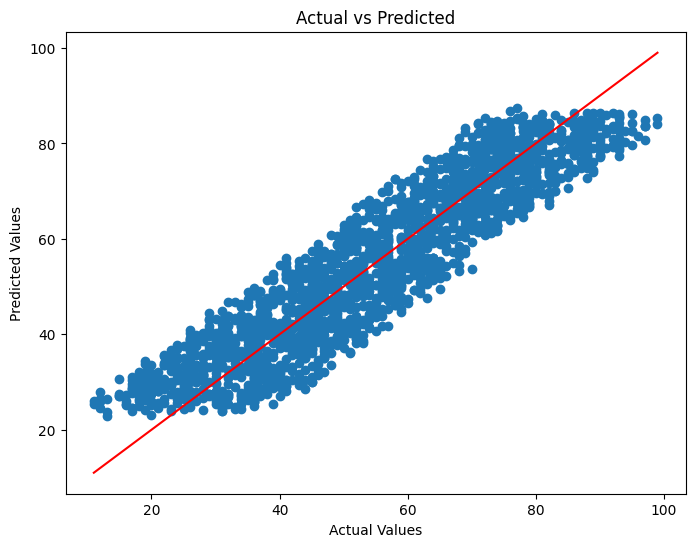

In [239]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

<center><b>Thank You</b></center>